<a href="https://colab.research.google.com/github/bababubu724/Analisis-Konsumsi-Daya-Listrik-Rumah-Tangga---BigData/blob/main/Big_Data_Project_Kelompok_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Konsumsi Daya Listrik Rumah Tangga Menggunakan Pendekatan Data Quality, Descriptive, dan Predictive Analytics

Dataset : (Individual Household Electric Power Consumption - UCI ML Repository)

**Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**1. Load Dataset**

In [ ]:
filename = 'household_power_consumption.txt'
df = pd.read_csv(filename, sep=';', low_memory=False, na_values=['?'])

print("--- Informasi Awal Dataset ---")
print(df.info())

total_baris_awal = len(df)
print(f"\nTotal baris dataset : {total_baris_awal:,}")

--- Informasi Awal Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB
None

Total baris dataset : 2,075,259


**2. Data Quality (Pembersihan Data)**

In [ ]:
# 2.1 Cek duplikasi baris
n_dup = df.duplicated().sum()
print(f"\n--- Jumlah Baris Duplikat: {n_dup} ---")
if n_dup > 0:
    df.drop_duplicates(inplace=True)
    print(f"Baris duplikat telah dihapus. Sisa baris: {len(df):,}")

# 2.2 Menggabungkan kolom Date dan Time menjadi Datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                 format='%d/%m/%Y %H:%M:%S', errors='coerce')
df.drop(['Date', 'Time'], axis=1, inplace=True)

# 2.3 Memastikan semua kolom fitur bertipe numerik
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\n--- Missing Values Sebelum Pembersihan ---")
print(df.isnull().sum())

n_missing = df.isnull().sum().sum()

# 2.4 Menghapus baris yang memiliki missing values
df.dropna(inplace=True)

print("\n--- Missing Values Setelah Pembersihan ---")
print(df.isnull().sum())

# 2.5 Urutkan berdasarkan waktu & reset index (memastikan data kronologis)
df.sort_values('Datetime', inplace=True)
df.reset_index(drop=True, inplace=True)

# 2.6 Ringkasan deteksi outlier dengan metode IQR (informasi, tidak dihapus)
Q1 = df['Global_active_power'].quantile(0.25)
Q3 = df['Global_active_power'].quantile(0.75)
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR
n_outlier = (df['Global_active_power'] > batas_atas).sum()
print(f"\n--- Deteksi Outlier (IQR) pada Global_active_power ---")
print(f"Batas atas wajar     : {batas_atas:.2f} kW")
print(f"Jumlah data di atas batas : {n_outlier:,} baris ({n_outlier/len(df)*100:.2f}%)")
print("Catatan: nilai tinggi ini wajar terjadi saat penggunaan alat berdaya besar")
print("(contoh: AC/pemanas air & oven menyala bersamaan), sehingga tidak dihapus.")


--- Jumlah Baris Duplikat: 0 ---

--- Missing Values Sebelum Pembersihan ---
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
dtype: int64

--- Missing Values Setelah Pembersihan ---
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Datetime                 0
dtype: int64

--- Deteksi Outlier (IQR) pada Global_active_power ---
Batas atas wajar     : 3.36 kW
Jumlah data di atas batas : 94,907 baris (4.63%)
Catatan: nilai tinggi ini wajar terjadi saat penggunaan alat berdaya besar
(contoh: AC/pemanas air & oven menyala bersamaan), sehingga tidak dihapus.


**3. Data Descriptive (Eksplorasi)**

In [ ]:
print("\n--- Statistik Deskriptif ---")
print(df.describe())


--- Statistik Deskriptif ---
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          1.091615e+00           1.237145e-01  2.408399e+02   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02   
50%           6.020000e-01           1.000000e-01  2.410100e+02   
75%           1.528000e+00           1.940000e-01  2.428900e+02   
max           1.112200e+01           1.390000e+00  2.541500e+02   
std           1.057294e+00           1.127220e-01  3.239987e+00   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
count      2.049280e+06    2.049280e+06    2.049280e+06    2.049280e+06   
mean       4.627759e+00    1.121923e+00    1.298520e+00    6.458447e+00   
min        2.000000e-01    0.000000e+00    0.000000e+00    0.000000e+00   
25%        1.400000e+00    0.000000e+00    0.000000e+00    0.00000

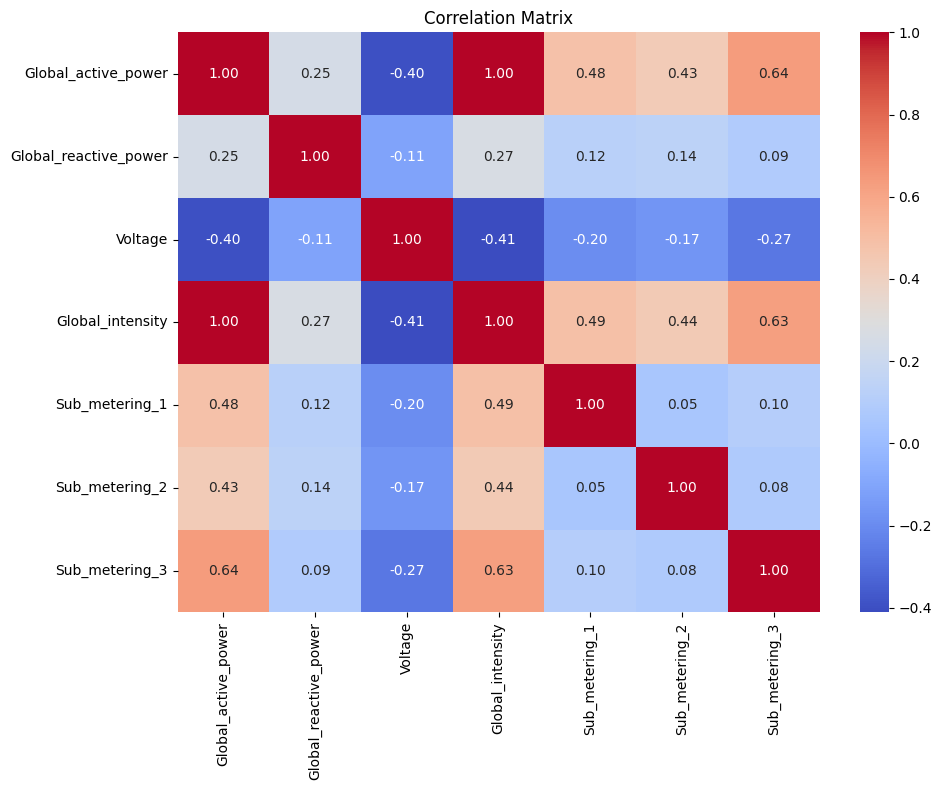

In [ ]:
# Visualisasi 1: Matriks Korelasi (Hubungan antar variabel)
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

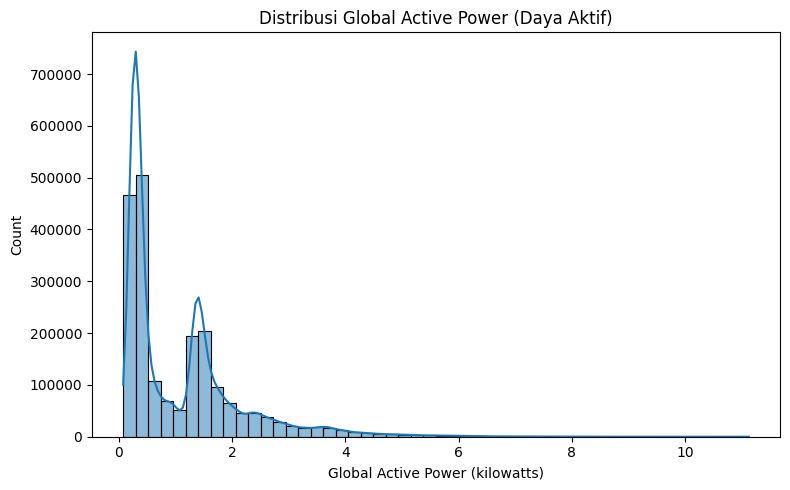

In [ ]:
# Visualisasi 2: Distribusi Penggunaan Daya Aktif
plt.figure(figsize=(8, 5))
sns.histplot(df['Global_active_power'], bins=50, kde=True)
plt.title("Distribusi Global Active Power (Daya Aktif)")
plt.xlabel("Global Active Power (kilowatts)")
plt.tight_layout()
plt.show()


Grafik Tren Runtut Waktu


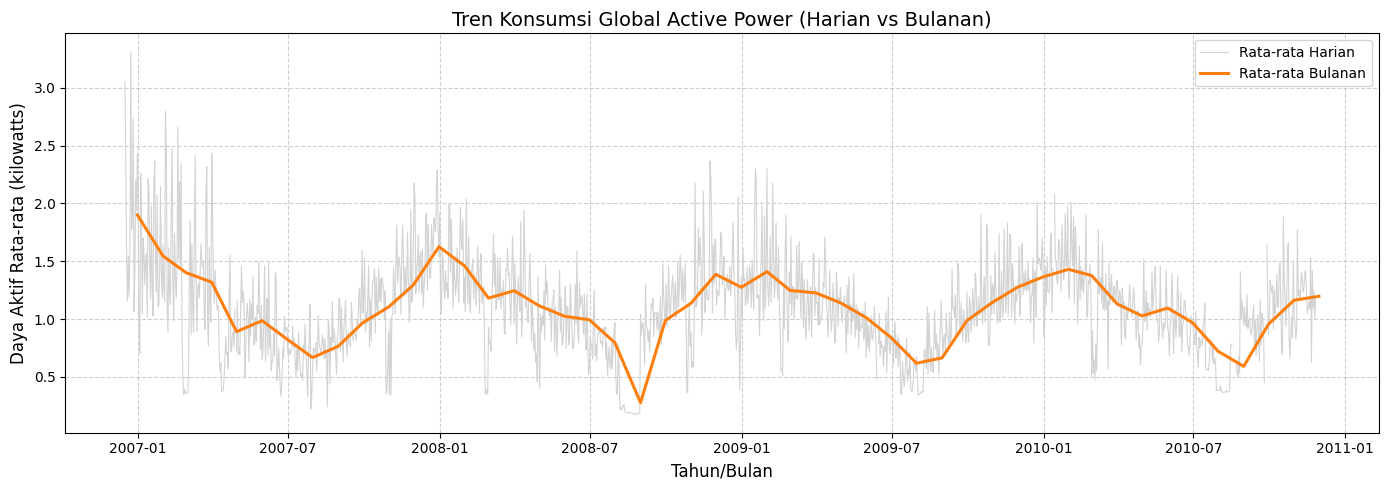

In [ ]:
# Siapkan dataframe berindeks Datetime untuk resampling
df_time = df.set_index('Datetime')

# Visualisasi 3: Tren Runtut Waktu (Harian vs Rata-rata Bulanan)
print("\nGrafik Tren Runtut Waktu")
df_daily = df_time['Global_active_power'].resample('D').mean()
df_monthly = df_time['Global_active_power'].resample('ME').mean()

plt.figure(figsize=(14, 5))
plt.plot(df_daily.index, df_daily.values, color='lightgray', linewidth=0.8, label='Rata-rata Harian')
plt.plot(df_monthly.index, df_monthly.values, color='tab:orange', linewidth=2.2, label='Rata-rata Bulanan')
plt.title("Tren Konsumsi Global Active Power (Harian vs Bulanan)", fontsize=14)
plt.xlabel("Tahun/Bulan", fontsize=12)
plt.ylabel("Daya Aktif Rata-rata (kilowatts)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Grafik Pola Konsumsi per Jam


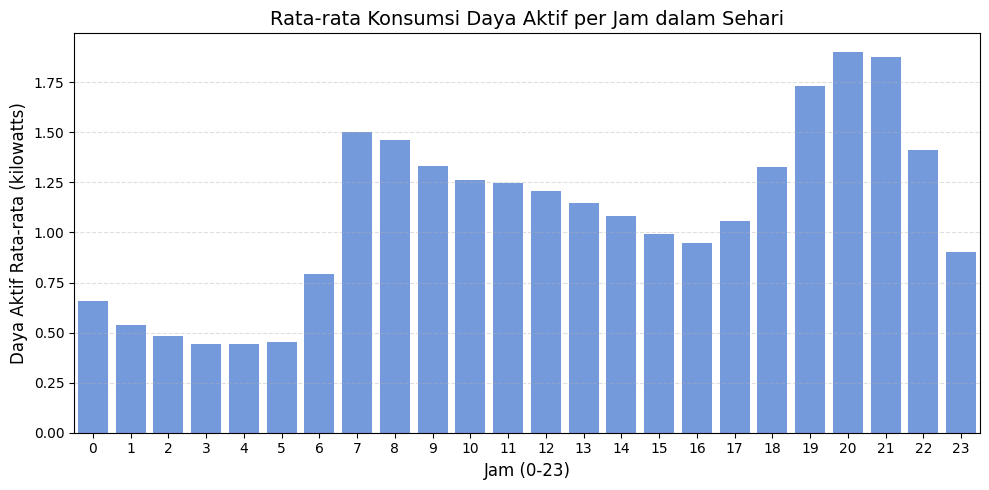

In [ ]:
# Visualisasi 4: Pola Konsumsi per Jam dalam Sehari
print("\nGrafik Pola Konsumsi per Jam")
df['Hour'] = df['Datetime'].dt.hour
hourly_avg = df.groupby('Hour')['Global_active_power'].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, color='cornflowerblue')
plt.title("Rata-rata Konsumsi Daya Aktif per Jam dalam Sehari", fontsize=14)
plt.xlabel("Jam (0-23)", fontsize=12)
plt.ylabel("Daya Aktif Rata-rata (kilowatts)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()


Grafik Pola Konsumsi per Hari


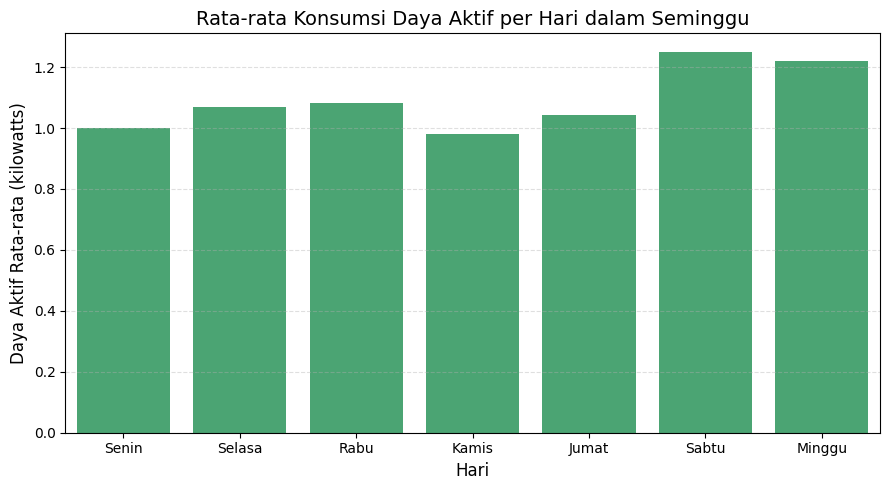

In [ ]:
# Visualisasi 5: Pola Konsumsi per Hari dalam Seminggu
print("\nGrafik Pola Konsumsi per Hari")
hari_map = {'Monday': 'Senin', 'Tuesday': 'Selasa', 'Wednesday': 'Rabu',
            'Thursday': 'Kamis', 'Friday': 'Jumat', 'Saturday': 'Sabtu', 'Sunday': 'Minggu'}
urutan_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']

df['Hari'] = df['Datetime'].dt.day_name().map(hari_map)
daily_avg = df.groupby('Hari')['Global_active_power'].mean().reindex(urutan_hari)

plt.figure(figsize=(9, 5))
sns.barplot(x=daily_avg.index, y=daily_avg.values, color='mediumseagreen')
plt.title("Rata-rata Konsumsi Daya Aktif per Hari dalam Seminggu", fontsize=14)
plt.xlabel("Hari", fontsize=12)
plt.ylabel("Daya Aktif Rata-rata (kilowatts)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()


Diagram Komposisi Sektoral


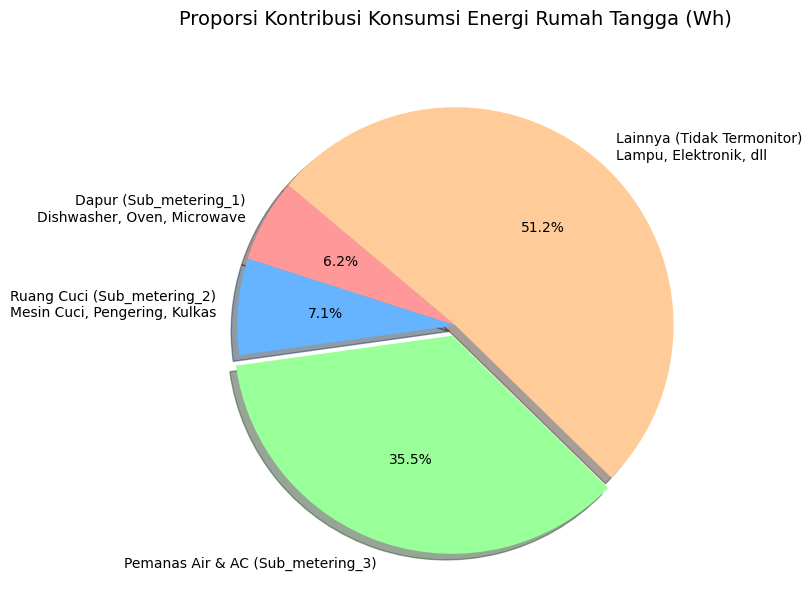

In [ ]:
# Visualisasi 6: Komposisi Sektoral (Pie Chart)
print("\nDiagram Komposisi Sektoral")
# Sub-metering dalam satuan Wh, sedangkan Global_active_power dalam kW.
# Konversi: Wh per menit = Global_active_power (kW) * 1000 / 60
total_energi_wh = (df['Global_active_power'] * 1000 / 60).sum()
total_sub1 = df['Sub_metering_1'].sum()
total_sub2 = df['Sub_metering_2'].sum()
total_sub3 = df['Sub_metering_3'].sum()
total_lainnya = total_energi_wh - (total_sub1 + total_sub2 + total_sub3)

energi_totals = [total_sub1, total_sub2, total_sub3, total_lainnya]
labels = ['Dapur (Sub_metering_1)\nDishwasher, Oven, Microwave',
          'Ruang Cuci (Sub_metering_2)\nMesin Cuci, Pengering, Kulkas',
          'Pemanas Air & AC (Sub_metering_3)',
          'Lainnya (Tidak Termonitor)\nLampu, Elektronik, dll']
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
explode = (0, 0, 0.05, 0)

plt.figure(figsize=(8, 8))
plt.pie(energi_totals, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 10})
plt.title("Proporsi Kontribusi Konsumsi Energi Rumah Tangga (Wh)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


Diagram Boxplot Outlier


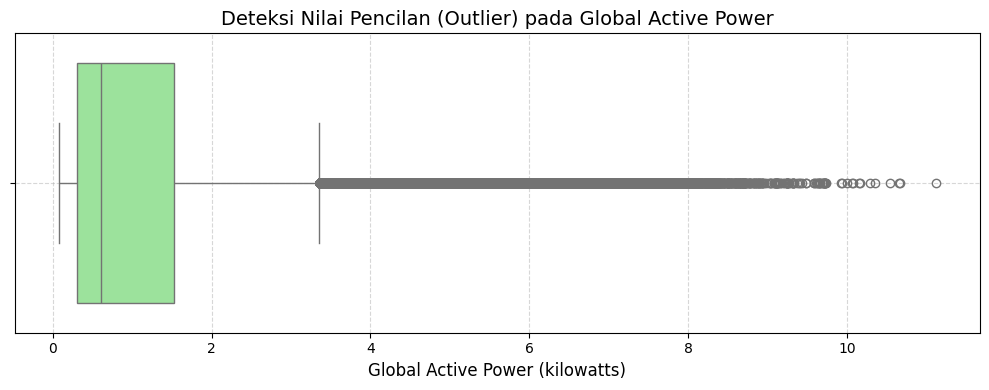

In [ ]:
# Visualisasi 7: Deteksi Pencilan (Boxplot)
print("\nDiagram Boxplot Outlier")
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Global_active_power'], color='lightgreen')
plt.title("Deteksi Nilai Pencilan (Outlier) pada Global Active Power", fontsize=14)
plt.xlabel("Global Active Power (kilowatts)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**4. Diagnostic Analytics**


[Diagnostic 1: Komposisi Sub-metering pada Konsumsi Normal vs Tinggi]
                  Sub_metering_1  Sub_metering_2  Sub_metering_3
Segmen_Konsumsi                                                 
Normal                  0.366404        0.729443        6.051739
Tinggi (Outlier)       16.679960       13.017248       14.833584


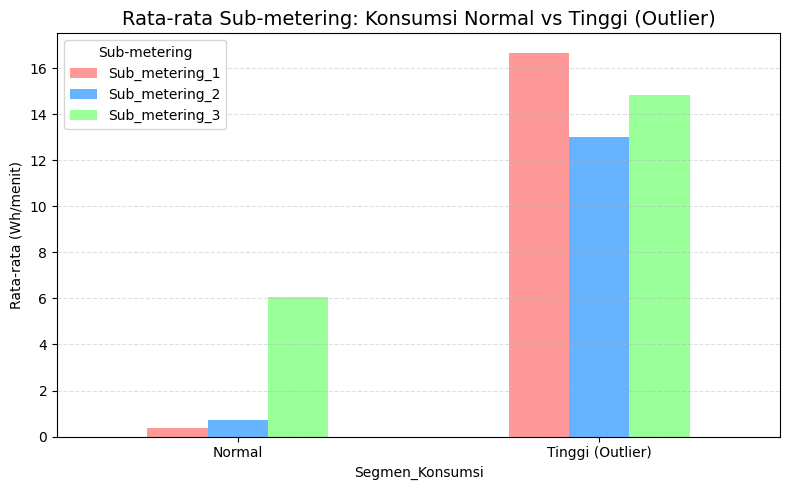

In [ ]:
# 4.1 Komposisi Sub-metering: Konsumsi Normal vs Tinggi (Outlier)
# Menjawab: APA penyebab lonjakan konsumsi (Global_active_power > batas IQR)?
print("\n[Diagnostic 1: Komposisi Sub-metering pada Konsumsi Normal vs Tinggi]")
df['Segmen_Konsumsi'] = np.where(df['Global_active_power'] > batas_atas, 'Tinggi (Outlier)', 'Normal')
segmen_avg = df.groupby('Segmen_Konsumsi')[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].mean()
print(segmen_avg)

segmen_avg.plot(kind='bar', figsize=(8, 5), color=['#ff9999', '#66b3ff', '#99ff99'])
plt.title("Rata-rata Sub-metering: Konsumsi Normal vs Tinggi (Outlier)", fontsize=14)
plt.ylabel("Rata-rata (Wh/menit)")
plt.xticks(rotation=0)
plt.legend(title='Sub-metering')
plt.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()


[Diagnostic 2: Kontribusi Sub-metering per Jam]


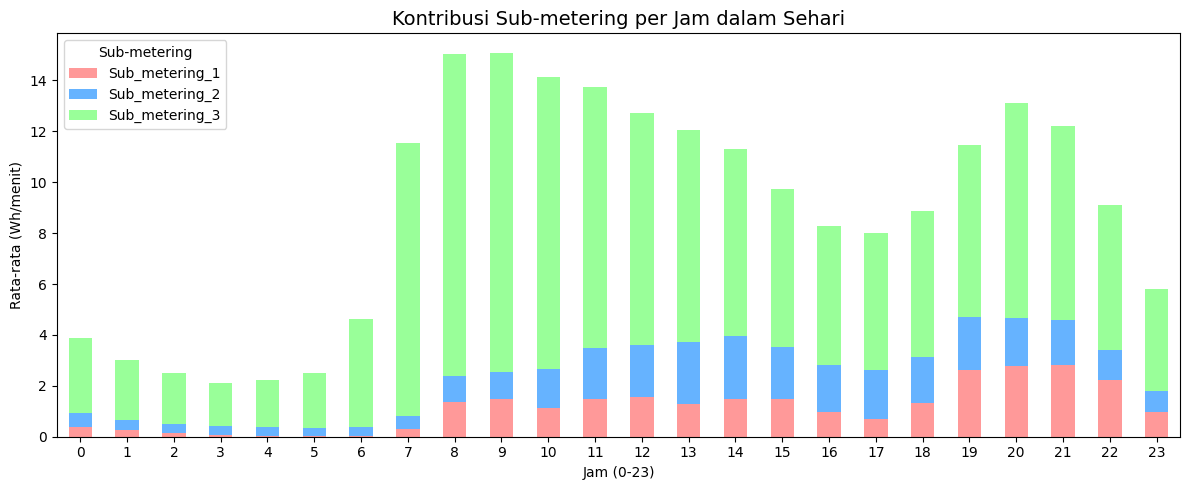

In [ ]:
# 4.2 Kontribusi Sub-metering per Jam (Stacked Bar)
# Menjawab: KELOMPOK ALAT APA yang mendorong beban puncak jam 18-21?
print("\n[Diagnostic 2: Kontribusi Sub-metering per Jam]")
hourly_sub = df.groupby('Hour')[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].mean()

hourly_sub.plot(kind='bar', stacked=True, figsize=(12, 5), color=['#ff9999', '#66b3ff', '#99ff99'])
plt.title("Kontribusi Sub-metering per Jam dalam Sehari", fontsize=14)
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata (Wh/menit)")
plt.legend(title='Sub-metering')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


[Diagnostic 3: Voltage Rata-rata berdasarkan Tingkat Konsumsi]
Segmen_Daya
<0.5     241.877348
0.5-1    241.447350
1-1.5    240.228381
1.5-2    240.214366
2-3      239.160693
>3       237.214667
Name: Voltage, dtype: float64


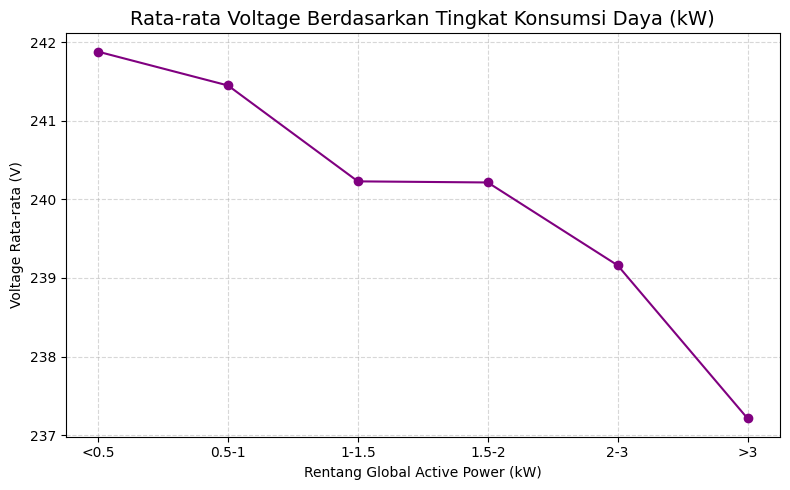

In [ ]:
# 4.3 Hubungan Voltage vs Tingkat Konsumsi (Diagnosa Voltage Drop)
# Menjawab: MENGAPA Voltage berkorelasi negatif (-0.40) dengan Global_active_power?
print("\n[Diagnostic 3: Voltage Rata-rata berdasarkan Tingkat Konsumsi]")
bins_gap = [0, 0.5, 1, 1.5, 2, 3, df['Global_active_power'].max()]
labels_gap = ['<0.5', '0.5-1', '1-1.5', '1.5-2', '2-3', '>3']
df['Segmen_Daya'] = pd.cut(df['Global_active_power'], bins=bins_gap, labels=labels_gap)
voltage_per_bin = df.groupby('Segmen_Daya', observed=False)['Voltage'].mean()
print(voltage_per_bin)

plt.figure(figsize=(8, 5))
voltage_per_bin.plot(kind='line', marker='o', color='purple')
plt.title("Rata-rata Voltage Berdasarkan Tingkat Konsumsi Daya (kW)", fontsize=14)
plt.xlabel("Rentang Global Active Power (kW)")
plt.ylabel("Voltage Rata-rata (V)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**5. Predictive Analysis (Linear Regression vs Random Forest)**

In [ ]:
features = ['Voltage', 'Global_reactive_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
X = df[features]
y = df['Global_active_power']

# Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# ---------- Model 1: Linear Regression ----------
print("\n[Melatih Model 1: Linear Regression...]")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Evaluasi Model 1: Linear Regression ---")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"MAE  : {mae_lr:.4f}")
print(f"R2   : {r2_lr:.4f}")

print("\nKoefisien Linear Regression (pengaruh tiap fitur terhadap Global_active_power):")
for fitur, koef in zip(features, lr_model.coef_):
    print(f"  {fitur:<22}: {koef:>8.4f}")
print(f"  Intercept            : {lr_model.intercept_:>8.4f}")


[Melatih Model 1: Linear Regression...]

--- Evaluasi Model 1: Linear Regression ---
MSE  : 0.2896
RMSE : 0.5382
MAE  : 0.3663
R2   : 0.7423

Koefisien Linear Regression (pengaruh tiap fitur terhadap Global_active_power):
  Voltage               :  -0.0378
  Global_reactive_power :   0.8672
  Sub_metering_1        :   0.0648
  Sub_metering_2        :   0.0614
  Sub_metering_3        :   0.0668
  Intercept            :   9.5140


In [ ]:
# ---------- Model 2: Random Forest Regressor ----------
print("\n[Melatih Model 2: Random Forest Regressor...]")
# n_estimators dapat dinaikkan (misal 50-100) jika perangkat cukup kuat
rf_model = RandomForestRegressor(n_estimators=30, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Evaluasi Model 2: Random Forest Regressor ---")
print(f"MSE  : {mse_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R2   : {r2_rf:.4f}")

print("\nFeature Importance Random Forest (kontribusi tiap fitur terhadap prediksi):")
importances = sorted(zip(features, rf_model.feature_importances_), key=lambda x: x[1], reverse=True)
for fitur, imp in importances:
    print(f"  {fitur:<22}: {imp:>8.4f}")


[Melatih Model 2: Random Forest Regressor...]

--- Evaluasi Model 2: Random Forest Regressor ---
MSE  : 0.2543
RMSE : 0.5043
MAE  : 0.3301
R2   : 0.7737

Feature Importance Random Forest (kontribusi tiap fitur terhadap prediksi):
  Sub_metering_3        :   0.5390
  Sub_metering_1        :   0.2224
  Sub_metering_2        :   0.1695
  Global_reactive_power :   0.0414
  Voltage               :   0.0277


In [ ]:
# ---------- Tabel Perbandingan Model ----------
print("\n--- Perbandingan Performa Model ---")
hasil_perbandingan = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MSE': [mse_lr, mse_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf],
    'R2': [r2_lr, r2_rf]
})
print(hasil_perbandingan.to_string(index=False))


--- Perbandingan Performa Model ---
            Model      MSE     RMSE      MAE       R2
Linear Regression 0.289628 0.538171 0.366309 0.742311
    Random Forest 0.254310 0.504291 0.330103 0.773734


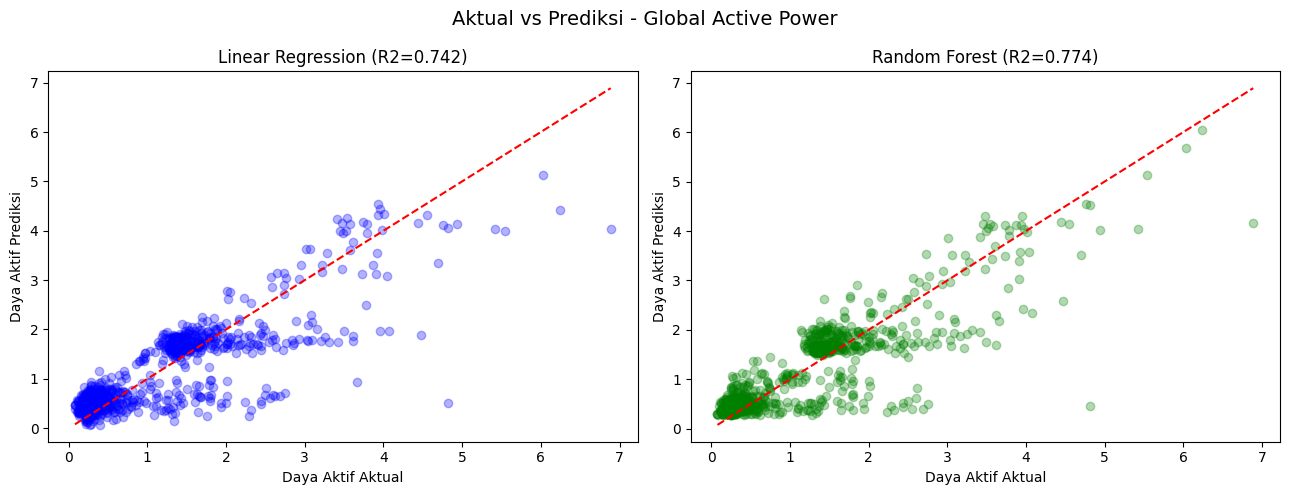

In [ ]:
# Visualisasi 8: Aktual vs Prediksi (kedua model, 1000 sampel)
n_sample = 1000
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test[:n_sample], y_pred_lr[:n_sample], alpha=0.3, color='blue')
axes[0].plot([y_test[:n_sample].min(), y_test[:n_sample].max()],
              [y_test[:n_sample].min(), y_test[:n_sample].max()], 'r--')
axes[0].set_xlabel("Daya Aktif Aktual")
axes[0].set_ylabel("Daya Aktif Prediksi")
axes[0].set_title(f"Linear Regression (R2={r2_lr:.3f})")

axes[1].scatter(y_test[:n_sample], y_pred_rf[:n_sample], alpha=0.3, color='green')
axes[1].plot([y_test[:n_sample].min(), y_test[:n_sample].max()],
              [y_test[:n_sample].min(), y_test[:n_sample].max()], 'r--')
axes[1].set_xlabel("Daya Aktif Aktual")
axes[1].set_ylabel("Daya Aktif Prediksi")
axes[1].set_title(f"Random Forest (R2={r2_rf:.3f})")

fig.suptitle("Aktual vs Prediksi - Global Active Power", fontsize=14)
plt.tight_layout()
plt.show()

**6. Hasil Analisis**

In [ ]:
print("\n" + "=" * 50)
print("RINGKASAN HASIL ANALISIS")
print("=" * 50)
print(f"1. DATA QUALITY  : {len(df):,} baris bersih dari total awal "
      f"{total_baris_awal:,} baris ({n_dup} duplikat & "
      f"{n_missing} missing value ditangani).")
print(f"2. DESCRIPTIVE   : Konsumsi rata-rata {df['Global_active_power'].mean():.2f} kW, "
      f"dengan beban tertinggi pada kategori Sub_metering_3 "
      f"(Pemanas Air & AC) yaitu {total_sub3/(total_sub1+total_sub2+total_sub3)*100:.1f}% "
      f"dari total yang termonitor.")
print(f"3. PREDICTIVE    : Random Forest (R2={r2_rf:.3f}) sedikit lebih akurat "
      f"dibanding Linear Regression (R2={r2_lr:.3f}) tanpa data leakage. "
      f"Fitur paling berpengaruh: {importances[0][0]}.")
print("=" * 50)


RINGKASAN HASIL ANALISIS
1. DATA QUALITY  : 2,049,280 baris bersih dari total awal 2,075,259 baris (0 duplikat & 181853 missing value ditangani).
2. DESCRIPTIVE   : Konsumsi rata-rata 1.09 kW, dengan beban tertinggi pada kategori Sub_metering_3 (Pemanas Air & AC) yaitu 72.7% dari total yang termonitor.
3. PREDICTIVE    : Random Forest (R2=0.774) sedikit lebih akurat dibanding Linear Regression (R2=0.742) tanpa data leakage. Fitur paling berpengaruh: Sub_metering_3.
